In [1]:
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
from numpy.linalg import inv

In [40]:
df=sns.load_dataset("tips")
df.shape

(244, 7)

In [41]:
df=df[['total_bill','tip','size']].iloc[0:10,:]

In [44]:
# formula
    ### simple linear regression, tip and bill
    ### calcuate sse,ssr,sst and r2
    ### building multiple linear regression by using tip, bill, size
    ### use matrix method to calculate , b0,b1,b2,y=tip
    ### SSE, SSR, SST

In [46]:
df

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4
5,25.29,4.71,4
6,8.77,2.00,2
7,26.88,3.12,4
8,15.04,1.96,2
9,14.78,3.23,2


### simple linear regression, tip and bill

In [81]:
x=df['tip']
y=df['total_bill']

In [89]:
xsum = x.sum()
ysum = y.sum()

In [117]:
x2sum = (x**2).sum()
y2sum = (y**2).sum()


In [133]:
sum_xy = (x*y).sum()

In [135]:
n = len(df)

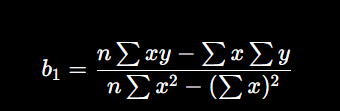

In [138]:
b1 = ((n*sum_xy) - (xsum*ysum)) / ((n*x2sum) - (xsum**2))

In [140]:
b1

4.115594802000761

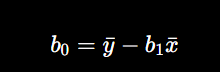

In [143]:
x_bar = xsum/n
y_bar = ysum/n

b0 = y_bar - b1*x_bar

print(b0)

7.168063011575862


In [149]:
print(f"y_bar = {b0:.4f} + {b1:.4f} X")

y_bar = 7.1681 + 4.1156 X


### calcuate sse,ssr,sst and r2

In [154]:
y_hat = b0 + b1*x

y_hat

0    11.324814
1    13.999950
2    21.572645
3    20.790682
4    22.025360
5    26.552515
6    15.399253
7    20.008719
8    15.234629
9    20.461434
Name: tip, dtype: float64

In [158]:
SST = ((y-y_bar)**2).sum()

SST

375.33601

In [160]:
SSE = ((y-y_hat)**2).sum()

SSE

185.80369159145607

In [162]:
SSR = ((y_hat-y_bar)**2).sum()

SSR

189.53231840854303

In [164]:
print(SST)
print(SSR + SSE)

375.33601
375.3360099999991


In [168]:
R2 = SSR/(SSR + SSE)

R2

0.5049670518119045

### building multiple linear regression by using tip, bill, size

In [177]:
x=df.drop('tip',axis=1)
y=df['tip']

In [179]:
x.shape,y.shape

((10, 2), (10,))

In [181]:
x['constant']=1

In [183]:
x.shape

(10, 3)

In [185]:
x.T.shape

(3, 10)

In [187]:
term1=inv(np.dot(x.T,x))

In [189]:
term1.shape

(3, 3)

In [191]:
x.T.shape

(3, 10)

In [193]:
term2=np.dot(term1,x.T)

In [195]:
term2.shape

(3, 10)

In [197]:
y.shape

(10,)

In [210]:
beta = np.dot(term2,y)

beta

array([0.09563268, 0.29043984, 0.205899  ])

In [201]:
x.columns

Index(['total_bill', 'size', 'constant'], dtype='object')

b0 = 0.205899  

b1 = 0.09563268

b2 = 0.29043984

total_tip = 0.205899   + 0.09563268(total_bill) + 0.29043984(size)

In [212]:
y_hat = np.dot(x, beta)
y_hat

array([2.41157784, 2.06606039, 3.08646104, 3.05136044, 3.71926586,
       3.78620873, 1.62547725, 3.93826469, 2.22509412, 2.20022963])

In [214]:
y_hat.shape

(10,)

### SSE, SSR, SST

In [216]:
y_bar = np.mean(y)
y_bar

2.8110000000000004

In [218]:
SSE = np.sum((y - y_hat)**2)

SSE

5.1730700159969505

In [220]:
SSR = np.sum((y_hat - y_bar)**2)

SSR

6.016619984003065

In [222]:
SST = np.sum((y - y_bar)**2)

SST

11.18969

In [224]:
print("SST =", SST)
print("SSR + SSE =", SSR + SSE)

SST = 11.18969
SSR + SSE = 11.189690000000017


In [226]:
R2 = SSR / SST

R2

0.5376931786316748